# Chapter 14: Building a World Inside

A planner evaluates tomorrow through an approximate transition model. Small one-step errors can matter more when the controller looks farther ahead. Yet a large worst-case bound does not mean the actual planning error reached it. Both quantities deserve separate places in the report.

This notebook compares two finite kernels under one fixed policy and one common immediate reward vector. It computes their transition mismatch, propagates finite-horizon values, and plots actual value error beside the chapter's conditional horizon bound. The changed case lengthens the horizon without changing the model. The transfer case makes the kernels identical, giving an exact zero-error check before any more complicated interpretation.

**Outcome:** Calculate uniform transition error, actual fixed-policy finite values, and conditional bounds.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

For each state, total variation between the true and modeled transition rows is half the sum of absolute probability differences. Uniform error epsilon is the maximum of those row distances. An average row error cannot replace that maximum in a uniform bound.

With common expected immediate rewards in [0,R], one fixed policy, and discount gamma<1, the chapter's discounted value bound is gamma epsilon R/(1-gamma)^2. This quantity applies under those prerequisites; it is not an estimate fitted to the finite error curve. Reward-model mismatch would need another term.

For H rewards and zero terminal continuation, the undiscounted finite-horizon bound is R epsilon H(H-1)/2. It also bounds the discounted finite calculation because discounting can only reduce these nonnegative error contributions. The implementation computes V_h=r+gamma P V_(h-1) and modeled W_h=r+gamma Q W_(h-1), starting both at zero, then records max_s |V_h(s)-W_h(s)|.

The kernels already absorb a fixed policy. A state-value bound alone does not provide the uniform action-value error and action gap needed to certify a choice ranking. Keep that missing prerequisite explicit.

## Apply this to an agent

An agent planning with an approximate environment model may assign the wrong value to a workflow state. Compare the model with a declared reference kernel and inspect both actual value error and the conditional bound. This fixed-policy calculation does not certify the best action.

## A calculation you can run

Provide two aligned square probability matrices and one nonnegative reward vector. Every row must sum to one. Declare discount and horizon. The function computes the uniform total-variation error, maximum reward, both finite value recurrences, the actual maximum error at each horizon, and the two conditional bounds.

Figures use reward horizon on the horizontal axis and reward units on the vertical axis. Plotting bound and actual error separately avoids disguising a small error beneath a large envelope. In the changed case increase horizon from five to twenty and predict how the quadratic envelope changes. Inspect the actual curve independently; it need not grow at the same rate. Export common-reward and fixed-policy assumptions with the numerical result.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 14
inputs = {'true_transition': [[0.9, 0.1], [0.2, 0.8]],
 'model_transition': [[0.88, 0.12], [0.22, 0.78]],
 'rewards': [0, 1],
 'discount': 0.9,
 'horizon': 5}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 14: transition-model-bound
How much value error can this approximate world model introduce?
Evidence: constructed teaching example

Calculated quantities:
{
  "uniform_tv_error": 0.02,
  "true_values": [
    0.55354113,
    2.98801774
  ],
  "model_values": [
    0.6403010023,
    2.921214829
  ],
  "max_finite_value_error": 0.08675987227,
  "discounted_infinite_bound": 1.8,
  "finite_horizon_bound": 0.2
}

Interpretation:
Both kernels share the same immediate reward vector under one fixed policy. The uniform total-variation error controls the conditional bound; the actual finite error can be much smaller.

Assumptions:
- Fixed policy absorbed into each transition matrix.
- Common expected immediate reward in [0,R].
- Finite calculation has zero terminal continuation; discounted bound assumes gamma below one.

Limitations:
- A bound is not a measured planning error.
- This state-value bound alone does not certify an action ranking.
- Reward-model error would require an addition

Both default row distances are 0.02, so epsilon=0.02. With R=1 and gamma=0.9, the discounted infinite bound is 1.8. At horizon 5 the finite bound is 0.02(5)(4)/2=0.2. The actual finite error is calculated from the two recurrences and must remain below the finite envelope.

At horizon 20 the finite bound grows to 3.8, even though each transition row changed by the same amount. That growth is a sensitivity statement under a worst-case construction. It does not say that the actual error became 3.8, and it does not establish that any particular action ranking reversed.

Two bounds are reported and both are valid. At horizon 20 the finite-horizon bound (3.8) is the looser one and the discounted infinite-horizon bound (1.8) the tighter, so the tightest valid statement is their minimum. The finite bound is not a stronger warning.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


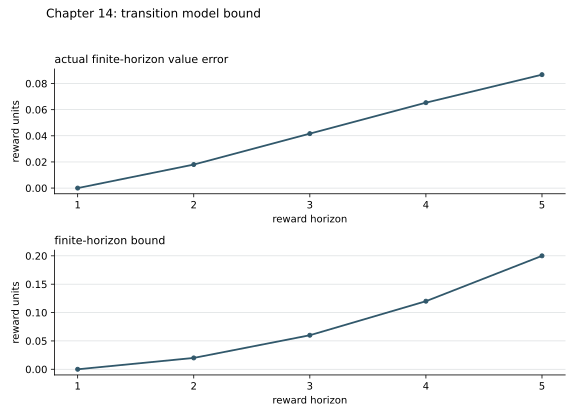

In [3]:
display(SVG(figure_svg(report)))

**Figure 14.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A common misuse inserts average model error into a uniform bound. A model may be accurate on frequently observed states and badly wrong at the one state that changes the plan. The maximum row distance protects the stated domain, while an average describes a different estimand.

Another misuse compares reward functions that differ and then attributes all value error to transition mismatch. This input contract intentionally supplies only one common reward vector. If the model invents immediate reward, the implementation's bound assumptions no longer apply.

Finally, an error bound is not a decision certificate. Even a small value bound can overwhelm a smaller action gap, and this fixed-policy state calculation does not inspect alternative actions. Use it to audit model sensitivity, then state the extra action-value and gap information required for ranking guarantees.

Chapter 14: transition-model-bound
How much value error can this approximate world model introduce?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "uniform_tv_error": 0.02,
  "true_values": [
    2.027264312,
    4.729704829
  ],
  "model_values": [
    2.231030443,
    4.694010975
  ],
  "max_finite_value_error": 0.2037661306,
  "discounted_infinite_bound": 1.8,
  "finite_horizon_bound": 3.8
}

Interpretation:
Both kernels share the same immediate reward vector under one fixed policy. The uniform total-variation error controls the conditional bound; the actual finite error can be much smaller.

Assumptions:
- Fixed policy absorbed into each transition matrix.
- Common expected immediate reward in [0,R].
- Finite calculation has zero terminal continuation; discounted bound assumes gamma below one.

Limitations:
- A bound is not a measured planning error.
- This state-value bound alone does not certify an action ranking.
- Reward-model error would require a

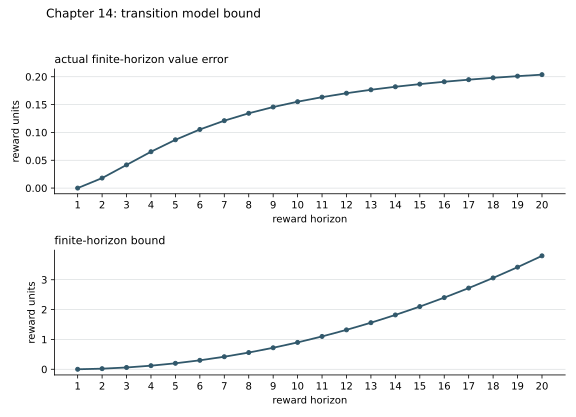

In [4]:
changed_inputs = {'true_transition': [[0.9, 0.1], [0.2, 0.8]],
 'model_transition': [[0.88, 0.12], [0.22, 0.78]],
 'rewards': [0, 1],
 'discount': 0.9,
 'horizon': 20}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 14.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer kernels are identical. Epsilon is zero, finite values agree at every stage, and both bounds are zero. This identity is a useful check of matrix alignment and recurrence behavior. If an implementation returned nonzero error here, investigate the computation before interpreting a more realistic model.

For reader data, explain how the true kernel was measured or constructed. Usually a deployed world does not provide exact transition probabilities. In that case the calculated epsilon is conditional on estimates and their support, not a known universal error. Preserve uncertainty or specify the measurements needed to bound it on the relevant policy domain.

In [5]:
transfer_inputs = {'true_transition': [[1, 0], [0, 1]],
 'model_transition': [[1, 0], [0, 1]],
 'rewards': [1, 2],
 'discount': 0.5,
 'horizon': 4}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 14: transition-model-bound
How much value error can this approximate world model introduce?
Evidence: constructed transfer example

Calculated quantities:
{
  "uniform_tv_error": 0.0,
  "true_values": [
    1.875,
    3.75
  ],
  "model_values": [
    1.875,
    3.75
  ],
  "max_finite_value_error": 0.0,
  "discounted_infinite_bound": 0.0,
  "finite_horizon_bound": 0.0
}

Interpretation:
Both kernels share the same immediate reward vector under one fixed policy. The uniform total-variation error controls the conditional bound; the actual finite error can be much smaller.

Assumptions:
- Fixed policy absorbed into each transition matrix.
- Common expected immediate reward in [0,R].
- Finite calculation has zero terminal continuation; discounted bound assumes gamma below one.

Limitations:
- A bound is not a measured planning error.
- This state-value bound alone does not certify an action ranking.
- Reward-model error would require an additional term.

Execution: completed local

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **true_transition:** Square row-stochastic true kernel after fixing a policy.
- **model_transition:** Same-size approximate row-stochastic kernel for that policy.
- **rewards:** Common immediate state reward vector, finite and nonnegative.
- **discount:** Gamma in [0,0.9999].
- **horizon:** Integer reward horizon 1..1000 with zero terminal continuation.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch14.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 14: transition-model-bound
How much value error can this approximate world model introduce?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "uniform_tv_error": 0.0,
  "true_values": [
    1.875,
    3.75
  ],
  "model_values": [
    1.875,
    3.75
  ],
  "max_finite_value_error": 0.0,
  "discounted_infinite_bound": 0.0,
  "finite_horizon_bound": 0.0
}

Interpretation:
Both kernels share the same immediate reward vector under one fixed policy. The uniform total-variation error controls the conditional bound; the actual finite error can be much smaller.

Assumptions:
- Fixed policy absorbed into each transition matrix.
- Common expected immediate reward in [0,R].
- Finite calculation has zero terminal continuation; discounted bound assumes gamma below one.

Limitations:
- A bound is not a measured planning error.
- This state-value bound alone does not certify an action ranking.
- Reward-model error would require an additional t

## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c14-d01"></a>

### Demonstration 1: The score inside the model against the score in the world

If you pick the setting that scores best inside the learned model, how does it do in the actual environment?

![Equation 14.1](../assets/math/52b47c925ae699342ab3.svg)

**Symbols and units:** Temperature is the sampling parameter of the imagined world: low values make it cleaner and more predictable, high values harder. The model score is the controller's score when evaluated in its own learned environment, and the actual score is its score in the real game. The random policy and the best leaderboard entry are the chapter's reference scores. The table does not report the transition error epsilon of Equation (14.1), which is the maximum over states and actions of half the summed difference between the model's and the true next-state probabilities.

The table has two columns because the researchers had two environments. Over the first four rows the columns run in opposite directions, so the setting that flatters the model most is the least useful in the world. Judging by the model column alone cannot show this; only the second column can. The scores do not supply the transition error epsilon or any action gap, so they do not give a certified horizon.

**Use in this chapter:** When a system proposes an action, predicts its outcome and scores itself on the prediction, it is reading the left column. Hold out some real outcomes and keep the second column, however small, and compare the two.

**Assumptions:** The scores are the chapter's reported numbers for one game setup and one training and evaluation procedure, each with its own variability (spreads were reported for 0.10 and 1.15 here). They show that the two evaluations can come apart, not a general temperature rule and not a measure of epsilon.

**Predict before running:** Rank the five settings by the model column alone. Which wins, and how does it score in the actual environment against the random policy's 210?

**Controls you can change:**

- **Setting to inspect (temperature):** `temperature` accepts 0.1, 1.0, 1.15, 1.3.
- **Pick the winner by:** `judge` accepts 'dream', 'real'.

**Source section:** The knob the authors added, and what it bought.

**Evidence:** source-reported game scores with a constructed judging comparison.

Constructed example (reported values in a constructed comparison): the scores are copied from the chapter's temperature table (reported by the cited paper for one game setup); the judging rule and the comparison are defined for this reader.

Prediction choices:

1. T = 0.10 wins and scores below the random policy in the actual environment
2. T = 0.10 wins and beats the best leaderboard entry in the actual environment
3. T = 1.15 wins and scores 1092 in the actual environment

**Boundary of the conclusion:** The anchor is a preprint reporting on its authors' own systems in one game, and the temperature that worked there is not a value to copy.

**Common wrong turn:** The chapter notes that an evaluation run only in the dream would have reported 2086 at the low setting, ranked it first, and been confidently wrong. Many agent evaluations have one column.

The score inside the model against the score in the world
Controls: {"temperature": 0.1, "judge": "dream"}
Evidence: source-reported game scores with a constructed judging comparison

Calculated quantities:
Temperature: 0.10
Score inside the model: 2086
Score in the actual environment: 193
Model minus actual: 1893
Actual minus random policy (210): -17
Picked by the dream column: 0.10
Picked: score in the actual environment: 193
Picked: actual minus random policy (210): -17
Reported spreads (model, actual): 2086 +/- 140, 193 +/- 58

Worked steps:
1. Read the chosen row: model 2086, actual 193.
2. Model minus actual: 2086 - 193 = 1893.
3. Actual minus the random policy's 210: 193 - 210 = -17.
4. Rank the five settings by the dream column alone: the largest is 2086 at T = 0.10.
5. That pick's actual score is 193: 193 - 210 = -17 against the random policy.
6. Spreads were reported only for 0.10 and 1.15; the table does not give the transition error of Equation (14.1).

At T = 0.10: model 2

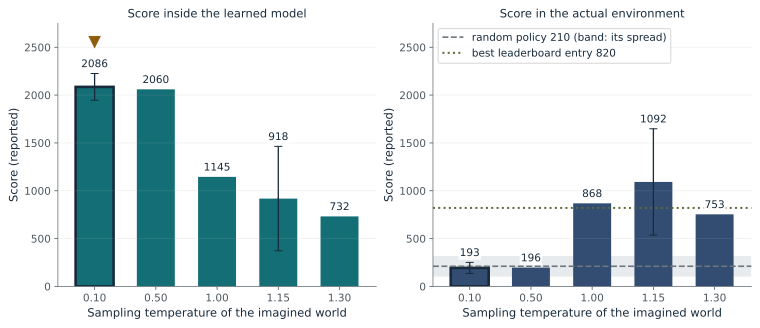

In [8]:
demo_id = 'C14-D01'
demo_controls = {'temperature': 0.1, 'judge': 'dream'}
demo_result = run_demo(14, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Setting to inspect (temperature)** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

The score inside the model against the score in the world
Controls: {"temperature": 1.0, "judge": "dream"}
Evidence: source-reported game scores with a constructed judging comparison

Calculated quantities:
Temperature: 1.00
Score inside the model: 1145
Score in the actual environment: 868
Model minus actual: 277
Actual minus random policy (210): 658
Picked by the dream column: 0.10
Picked: score in the actual environment: 193
Picked: actual minus random policy (210): -17

Worked steps:
1. Read the chosen row: model 1145, actual 868.
2. Model minus actual: 1145 - 868 = 277.
3. Actual minus the random policy's 210: 868 - 210 = 658.
4. Rank the five settings by the dream column alone: the largest is 2086 at T = 0.10.
5. That pick's actual score is 193: 193 - 210 = -17 against the random policy.
6. Spreads were reported only for 0.10 and 1.15; the table does not give the transition error of Equation (14.1).

At T = 1.00: model 1145 - actual 868 = 277. Actual against the random policy: 868

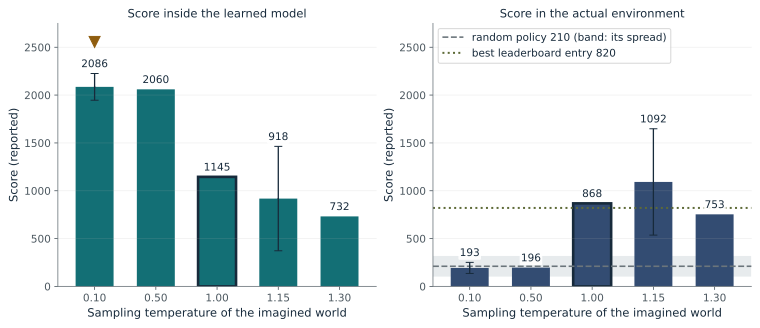

In [9]:
changed_controls = {'temperature': 1.0, 'judge': 'dream'}
changed_demo = run_demo(14, 'C14-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(14, 'C14-D01'):
    state = run_demo(14, 'C14-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "temperature": 0.1,
      "judge": "dream"
    },
    "metrics": [
      [
        "Temperature",
        "0.10"
      ],
      [
        "Score inside the model",
        "2086"
      ],
      [
        "Score in the actual environment",
        "193"
      ],
      [
        "Model minus actual",
        "1893"
      ],
      [
        "Actual minus random policy (210)",
        "-17"
      ],
      [
        "Picked by the dream column",
        "0.10"
      ],
      [
        "Picked: score in the actual environment",
        "193"
      ],
      [
        "Picked: actual minus random policy (210)",
        "-17"
      ],
      [
        "Reported spreads (model, actual)",
        "2086 +/- 140, 193 +/- 58"
      ]
    ]
  },
  {
    "controls": {
      "temperature": 0.1,
      "judge": "real"
    },
    "metrics": [
      [
        "Temperature",
        "0.10"
      ],
      [
        "Score inside the model",
        "2086"
      ],
      [
       

**Check your understanding:** At T = 1.30, what is the model score minus the actual score, and which column is higher?

[Answer and worked reasoning](../solutions/ch14.md#demonstration-1). [Matching browser demonstration](../readers/14-transition-model-bound/reader.html#C14-D01).

<a id="demo-c14-d02"></a>

### Demonstration 2: One step of error, compounded, against the actual error

How large can the value error become when a small one-step error compounds, and how large is it in a constructed model?

![Equation 14.1](../assets/math/52b47c925ae699342ab3.svg)

![Equation 14.2](../assets/math/b20fc29975e836ddc4c8.svg)

**Symbols and units:** P(x' | x, a) is the true probability of moving to state x' from state x after action a; the hat marks the model's estimate. Epsilon is the largest row error, half the summed absolute difference. V(x) is the true value of state x under a fixed behaviour and V-hat(x) the value the model computes, gamma the discount factor and R the largest immediate reward. The actual error is the largest gap between the two value recurrences after H rewards, and the finite bound R x epsilon x H(H-1)/2 is the chapter's finite-horizon envelope. The value scale R/(1-gamma) is the most any run could collect.

The bound multiplies gamma, epsilon and R, then divides by (1 - gamma) squared: one factor of 1/(1-gamma) counts the steps that matter and the second counts that a mistake at each step displaces everything after it. The finite bound grows with H(H-1) instead. Each bound holds under its own assumptions, and the actual error from the two recurrences stays under both. Raising gamma shrinks nothing in the finite bound but inflates the discounted one.

**Use in this chapter:** Before trusting a long imagined rollout, divide the bound by the largest possible value. If the share is near or above 1, the guarantee has nothing to say. If the model cannot be improved, consult the world more often.

**Assumptions:** The bound needs a fixed behaviour, the same expected immediate reward in model and world, rewards in [0, R], and error at most epsilon for every state and action that behaviour reaches. The kernels are the laboratory's constructed two-state defaults, so the actual error is that of one small model, not a general rate. A single number can also hide where the model is bad.

**Predict before running:** In the default case (error 0.02, R = 1) raise gamma to 0.99. About how large is the discounted bound?

**Controls you can change:**

- **Case:** `case` accepts 'default', 'changed', 'transfer', 'percent'.
- **Discount factor gamma:** `discount` accepts 0.5, 0.9, 0.99.

**Source section:** What one step of error becomes.

**Evidence:** constructed teaching example.

Constructed example: the laboratory's default, changed and transfer cases (kernels (0.90, 0.10), (0.20, 0.80) and model rows shifted by 0.02, horizons 5 and 20, identical kernels with rewards 1 and 2) and the chapter's 0.01 illustration, all computed with the laboratory's transition-model function.

Prediction choices:

1. About 2
2. About 20
3. About 200

**Boundary of the conclusion:** The bound in Equation (14.2) is worst case and often loose, and a model with a large error may perform far better than it permits.

**Common wrong turn:** The chapter says the bound is worst case and often loose, and that a model with a large error may perform far better than it permits. At horizon 20 the finite bound is 3.8 while the actual error stays small.

One step of error, compounded, against the actual error
Controls: {"case": "default", "discount": 0.9}
Evidence: constructed teaching example

Calculated quantities:
Epsilon (Equation 14.1): 0.020
Actual error after H = 5: 0.0868
Finite bound at H = 5: 0.200
Discounted bound (Equation 14.2): 1.800
Tightest valid bound: 0.200
Largest possible value R/(1-gamma): 10.0

Worked steps:
1. Row error by Equation (14.1): 1/2 x (|0.88 - 0.90| + |0.12 - 0.10|) = 1/2 x (0.02 + 0.02) = 0.02.
2. Epsilon is the largest row error: 0.02. Rewards are shared; R = 1.
3. Finite bound after H = 5: R x eps x H(H-1)/2 = 1 x 0.02 x 5 x 4 / 2 = 0.200.
4. Discounted bound by Equation (14.2): gamma x eps x R / (1-gamma)^2 = 1.800.
5. Each bound holds under its own assumptions; the smaller of the two numbers is 0.200.
6. Two rewards by hand (state 2): V = 1.00 + 0.90 x (0.20 x 0.00 + 0.80 x 1.00) = 1.720, model 1.00 + 0.90 x (0.22 x 0.00 + 0.78 x 1.00) = 1.702, difference 0.018.
7. Actual error after 5 rewards, fr

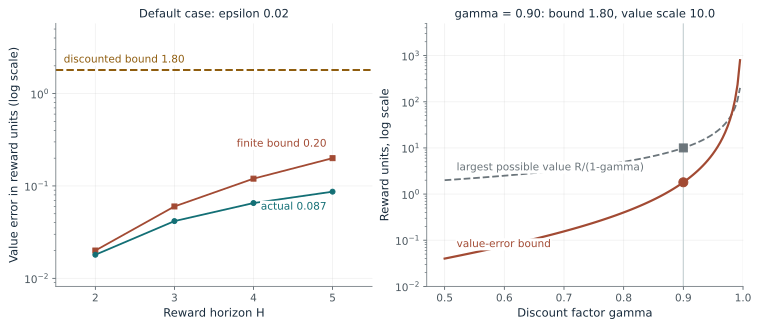

In [11]:
demo_id = 'C14-D02'
demo_controls = {'case': 'default', 'discount': 0.9}
demo_result = run_demo(14, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Case** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

One step of error, compounded, against the actual error
Controls: {"case": "changed", "discount": 0.9}
Evidence: constructed teaching example

Calculated quantities:
Epsilon (Equation 14.1): 0.020
Actual error after H = 20: 0.2038
Finite bound at H = 20: 3.800
Discounted bound (Equation 14.2): 1.800
Tightest valid bound: 1.800
Largest possible value R/(1-gamma): 10.0

Worked steps:
1. Row error by Equation (14.1): 1/2 x (|0.88 - 0.90| + |0.12 - 0.10|) = 1/2 x (0.02 + 0.02) = 0.02.
2. Epsilon is the largest row error: 0.02. Rewards are shared; R = 1.
3. Finite bound after H = 20: R x eps x H(H-1)/2 = 1 x 0.02 x 20 x 19 / 2 = 3.800.
4. Discounted bound by Equation (14.2): gamma x eps x R / (1-gamma)^2 = 1.800.
5. Each bound holds under its own assumptions; the smaller of the two numbers is 1.800.
6. Two rewards by hand (state 2): V = 1.00 + 0.90 x (0.20 x 0.00 + 0.80 x 1.00) = 1.720, model 1.00 + 0.90 x (0.22 x 0.00 + 0.78 x 1.00) = 1.702, difference 0.018.
7. Actual error after 20 rewar

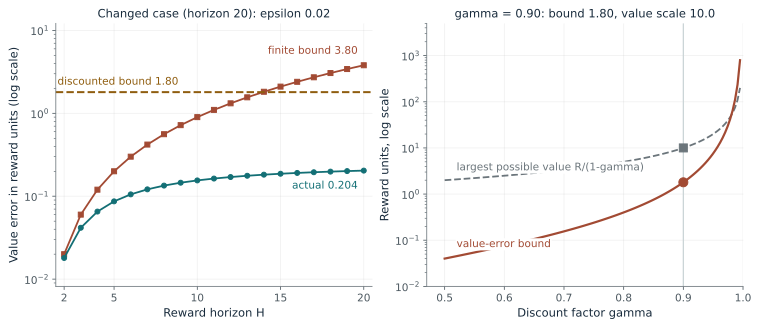

In [12]:
changed_controls = {'case': 'changed', 'discount': 0.9}
changed_demo = run_demo(14, 'C14-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(14, 'C14-D02'):
    state = run_demo(14, 'C14-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "case": "default",
      "discount": 0.5
    },
    "metrics": [
      [
        "Epsilon (Equation 14.1)",
        "0.020"
      ],
      [
        "Actual error after H = 5",
        "0.0234"
      ],
      [
        "Finite bound at H = 5",
        "0.200"
      ],
      [
        "Discounted bound (Equation 14.2)",
        "0.040"
      ],
      [
        "Tightest valid bound",
        "0.040"
      ],
      [
        "Largest possible value R/(1-gamma)",
        "2.0"
      ]
    ]
  },
  {
    "controls": {
      "case": "default",
      "discount": 0.9
    },
    "metrics": [
      [
        "Epsilon (Equation 14.1)",
        "0.020"
      ],
      [
        "Actual error after H = 5",
        "0.0868"
      ],
      [
        "Finite bound at H = 5",
        "0.200"
      ],
      [
        "Discounted bound (Equation 14.2)",
        "1.800"
      ],
      [
        "Tightest valid bound",
        "0.200"
      ],
      [
        "Largest possible

**Check your understanding:** With gamma = 0.8, epsilon = 0.05 and R = 1, what is the discounted bound, and what is the largest possible value?

[Answer and worked reasoning](../solutions/ch14.md#demonstration-2). [Matching browser demonstration](../readers/14-transition-model-bound/reader.html#C14-D02).

<a id="demo-c14-d03"></a>

### Demonstration 3: The optimizer finds where the model is generous, and the gap decides

A model can be wrong about every action value and still choose correctly, or be right about eleven tools and choose the twelfth. What decides which?

![Equation 14.3](../assets/math/02d58a83dac048591dea.svg)

**Symbols and units:** Q(x, a) is the true value of taking action a at state x and then following the fixed behaviour; here the twelve options are tools with constructed values. Delta is the gap between the best action's value and the runner-up's (a* is a best action; if several actions tie for the maximum, the gap is defined as zero). The model's value of each action is off by the chosen error, and the chapter's ranking guarantee is that the model keeps the true ranking whenever twice that error is smaller than the gap: 2 delta < Delta. The largest error is the maximum over options, the average is the mean.

A shared offset moves every value together, so the ordering is untouched however large the offset is. One favorable error on a tool that is truly poor changes the choice only if it lifts that tool above the best, but when it does, the average error is tiny (the error divided by twelve) while the largest is the whole error: this is why Equation (14.1) is a maximum and not an average. An adversarial error marks the best down and the runner-up up, so the two meet when twice the error equals the gap.

**Use in this chapter:** Judge a planning model against the decision it serves, not against a single accuracy figure. Ask how large the gap is between the best option and the next one, compare twice the value error to it in the same units, and check whether the errors are concentrated on options the optimizer will rank.

**Assumptions:** Twelve options with constructed values, a uniform bound on the action-value error, and three hand-made error patterns. The chapter adds that this bound is an extra assumption: Equation (14.2) bounds state values and does not supply it. The test 2 x error < gap is sufficient, not necessary, so a failed test leaves the ranking undecided rather than wrong.

**Predict before running:** Use the adversarial pattern with error 0.15, where twice the error equals the gap 0.30. What does the model do with tools 5 and 6?

**Controls you can change:**

- **Error pattern:** `pattern` accepts 'shared', 'favorable', 'adversarial'.
- **Size of the error:** `error` accepts 0.05, 0.15, 0.3, 0.9.

**Source section:** The number that actually matters.

**Evidence:** constructed teaching example.

Constructed example: twelve option values defined for this reader (best 0.90, runner-up 0.60), with error patterns that illustrate the chapter's ranking argument and its eleven-right, one-wrong tool example.

Prediction choices:

1. It still picks tool 6
2. It scores tools 5 and 6 equally, a tie
3. It picks tool 5

**Boundary of the conclusion:** This schematic explains the selection mechanism rather than supplying a measured error landscape.

**Common wrong turn:** The chapter says the useful question is never how accurate the model is, but whether its error is small relative to the gaps in the decision it serves, and that the diagnostic is whether errors are correlated across the options it ranks, not the average.

The optimizer finds where the model is generous, and the gap decides
Controls: {"pattern": "shared", "error": 0.05}
Evidence: constructed teaching example

Calculated quantities:
True gap (Equation 14.3): 0.30
Largest error: 0.050
Average error over 12 tools: 0.050
Twice the largest error: 0.10
Guarantee 2 x error < gap holds: yes
Model's pick: tool 6
Model's value of the pick: 0.95
True value of the pick: 0.90

Worked steps:
1. True values: tool 6 is best at 0.90, tool 5 is next at 0.60, tool 12 is lowest at 0.10.
2. Gap by Equation (14.3): 0.90 - 0.60 = 0.30.
3. Error pattern: the same offset on every tool, size 0.05.
4. Model values: tool 5 0.65, tool 6 0.95, tool 12 0.15.
5. Largest error 0.05; average error 0.60 / 12 = 0.050.
6. Guarantee test: 2 x 0.05 = 0.10 against the gap 0.30: holds.
7. The optimizer takes the highest model value: tool 6, true value 0.90.

Gap = 0.90 - 0.60 = 0.30. Twice the largest error = 2 x 0.05 = 0.10. Error pattern: the same offset on every tool. Averag

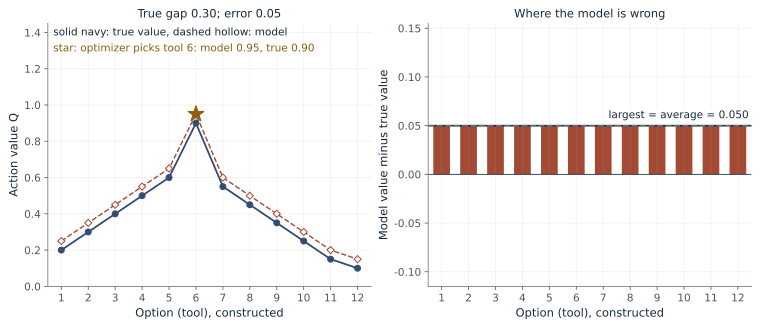

In [14]:
demo_id = 'C14-D03'
demo_controls = {'pattern': 'shared', 'error': 0.05}
demo_result = run_demo(14, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Error pattern** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

The optimizer finds where the model is generous, and the gap decides
Controls: {"pattern": "favorable", "error": 0.05}
Evidence: constructed teaching example

Calculated quantities:
True gap (Equation 14.3): 0.30
Largest error: 0.050
Average error over 12 tools: 0.004
Twice the largest error: 0.10
Guarantee 2 x error < gap holds: yes
Model's pick: tool 6
Model's value of the pick: 0.90
True value of the pick: 0.90

Worked steps:
1. True values: tool 6 is best at 0.90, tool 5 is next at 0.60, tool 12 is lowest at 0.10.
2. Gap by Equation (14.3): 0.90 - 0.60 = 0.30.
3. Error pattern: one favorable error on tool 12 only, size 0.05.
4. Model values: tool 5 0.60, tool 6 0.90, tool 12 0.15.
5. Largest error 0.05; average error 0.05 / 12 = 0.004.
6. Guarantee test: 2 x 0.05 = 0.10 against the gap 0.30: holds.
7. The optimizer takes the highest model value: tool 6, true value 0.90.

Gap = 0.90 - 0.60 = 0.30. Twice the largest error = 2 x 0.05 = 0.10. Error pattern: one favorable error on tool 

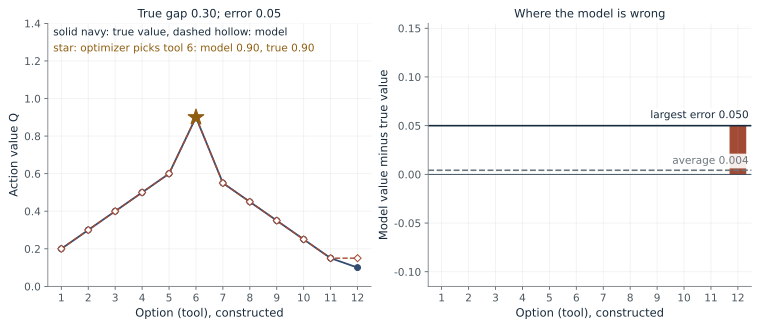

In [15]:
changed_controls = {'pattern': 'favorable', 'error': 0.05}
changed_demo = run_demo(14, 'C14-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(14, 'C14-D03'):
    state = run_demo(14, 'C14-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "pattern": "shared",
      "error": 0.05
    },
    "metrics": [
      [
        "True gap (Equation 14.3)",
        "0.30"
      ],
      [
        "Largest error",
        "0.050"
      ],
      [
        "Average error over 12 tools",
        "0.050"
      ],
      [
        "Twice the largest error",
        "0.10"
      ],
      [
        "Guarantee 2 x error < gap holds",
        "yes"
      ],
      [
        "Model's pick",
        "tool 6"
      ],
      [
        "Model's value of the pick",
        "0.95"
      ],
      [
        "True value of the pick",
        "0.90"
      ]
    ]
  },
  {
    "controls": {
      "pattern": "shared",
      "error": 0.15
    },
    "metrics": [
      [
        "True gap (Equation 14.3)",
        "0.30"
      ],
      [
        "Largest error",
        "0.150"
      ],
      [
        "Average error over 12 tools",
        "0.150"
      ],
      [
        "Twice the largest error",
        "0.30"
      ],
     

**Check your understanding:** True values 0.90 and 0.60, adversarial error 0.12. Which action does the model pick, and does the guarantee hold?

[Answer and worked reasoning](../solutions/ch14.md#demonstration-3). [Matching browser demonstration](../readers/14-transition-model-bound/reader.html#C14-D03).

<a id="demo-c14-d04"></a>

### Demonstration 4: How many imagined steps are certified

Given the model error, the reward range and the action gap, how many steps ahead can the certificate vouch for?

![Equation 14.4](../assets/math/b90bd3f384ebe300fc72.svg)

**Symbols and units:** H is the number of rewards the agent plans over, H-max the declared planning cap (9 here), and H-star the largest H that passes. R is the largest immediate reward, epsilon the uniform one-step error from Equation (14.1), and Delta the lower bound on the action gap from Equation (14.3). The left side R x epsilon x H(H-1) is twice the finite-horizon action-value error bound R x epsilon x H(H-1)/2.

Twice the error bound grows with H times H-1, so each extra step costs more than the last. The certificate keeps the largest H for which that quantity is still strictly below the gap. Because H(H-1) grows like H squared, the horizon scales roughly with the square root of gap over R x epsilon: for long horizons, cutting the error by 8 times raises it by about 2.8 times, not 8. A twenty-step plan committed in advance fails the test by a wide margin, which is why the countermeasure is to plan a few steps, look, and replan.

**Use in this chapter:** Use the certified horizon to set how many steps an agent commits to before it observes the world again. Plan that many, execute a few, look, and replan, rather than emitting a long plan against an error nobody measured.

**Assumptions:** A finite covered domain, equal expected immediate rewards in model and world, the same initial state and fixed behaviour, uniform error epsilon, zero terminal continuation and a declared gap. The R = 10 case uses the chapter's priced plan, where a logged prediction miss rate is declared a conservative proxy for epsilon, which is not the same thing. A failed test is inconclusive, not proof of a wrong decision, and the inputs are usually not measured.

**Predict before running:** With R = 10 and a gap of 2, cut the error by 8 times, from 0.08 to 0.01. Does the certified horizon grow by 8 times, or by far less?

**Controls you can change:**

- **Reward range and action gap:** `scenario` accepts 'r1', 'r1small', 'r10'.
- **One-step error epsilon:** `error` accepts 0.01, 0.02, 0.04, 0.08.

**Source section:** How many steps a model is good for.

**Evidence:** constructed teaching example.

Constructed example: the chapter's Figure 14.2 gaps (R = 1, epsilon 0.02, gaps 0.2 and 0.5) and its priced twenty-step plan (R = 10, gap 2, epsilon 0.08 and 0.01); the other error values are defined for this reader, and each curve is checked against the laboratory's finite-horizon bound.

Prediction choices:

1. It grows from 2 to 4
2. It grows from 2 to 16
3. It stays at 2

**Boundary of the conclusion:** The horizon arithmetic is constructed for teaching. How to bound what a system could achieve given a model, rather than what it does achieve, waits for Chapters 24 and 26.

**Common wrong turn:** The chapter says the certificate's failure at six is inconclusive, not evidence that the model must make a wrong decision there. It only says this sufficient guarantee stops.

How many imagined steps are certified
Controls: {"scenario": "r1", "error": 0.02}
Evidence: constructed teaching example

Calculated quantities:
Certified horizon H*: 5
First horizon that fails: 6
R x epsilon x H(H-1) at H* = 5: 0.40
Action gap: 0.5
Same quantity at a twenty-step plan: 7.6

Worked steps:
1. Inputs: R = 1, epsilon = 0.02, action gap = 0.5, planning cap 9.
2. Test each H: R x epsilon x H(H-1) must be strictly below 0.5.
3. Largest H that passes: H* = 5, because 1 x 0.02 x 5 x 4 = 0.40.
4. First failure at H = 6: 1 x 0.02 x 6 x 5 = 0.60.
5. Twenty steps: 1 x 0.02 x 20 x 19 = 7.6, far above the gap.

At H = 5: 1 x 0.02 x 5 x 4 = 0.40, below the gap 0.5. At H = 6: 1 x 0.02 x 6 x 5 = 0.60, not below the gap 0.5. The certificate covers 5 rewards. Its failure at 6 is inconclusive: it does not show that the ranking reverses, only that this guarantee stops. A twenty-step plan committed in advance would need 1 x 0.02 x 20 x 19 = 7.6 to be below the gap 0.5, which it is not: plan 

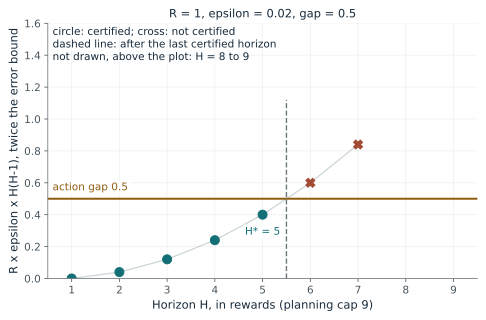

In [17]:
demo_id = 'C14-D04'
demo_controls = {'scenario': 'r1', 'error': 0.02}
demo_result = run_demo(14, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Reward range and action gap** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

How many imagined steps are certified
Controls: {"scenario": "r1small", "error": 0.02}
Evidence: constructed teaching example

Calculated quantities:
Certified horizon H*: 3
First horizon that fails: 4
R x epsilon x H(H-1) at H* = 3: 0.12
Action gap: 0.2
Same quantity at a twenty-step plan: 7.6

Worked steps:
1. Inputs: R = 1, epsilon = 0.02, action gap = 0.2, planning cap 9.
2. Test each H: R x epsilon x H(H-1) must be strictly below 0.2.
3. Largest H that passes: H* = 3, because 1 x 0.02 x 3 x 2 = 0.12.
4. First failure at H = 4: 1 x 0.02 x 4 x 3 = 0.24.
5. Twenty steps: 1 x 0.02 x 20 x 19 = 7.6, far above the gap.

At H = 3: 1 x 0.02 x 3 x 2 = 0.12, below the gap 0.2. At H = 4: 1 x 0.02 x 4 x 3 = 0.24, not below the gap 0.2. The certificate covers 3 rewards. Its failure at 4 is inconclusive: it does not show that the ranking reverses, only that this guarantee stops. A twenty-step plan committed in advance would need 1 x 0.02 x 20 x 19 = 7.6 to be below the gap 0.2, which it is not: 

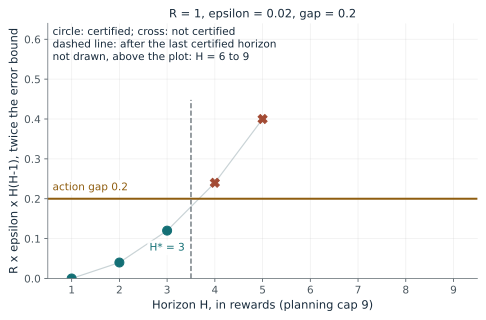

In [18]:
changed_controls = {'scenario': 'r1small', 'error': 0.02}
changed_demo = run_demo(14, 'C14-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(14, 'C14-D04'):
    state = run_demo(14, 'C14-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "scenario": "r1",
      "error": 0.01
    },
    "metrics": [
      [
        "Certified horizon H*",
        "7"
      ],
      [
        "First horizon that fails",
        "8"
      ],
      [
        "R x epsilon x H(H-1) at H* = 7",
        "0.42"
      ],
      [
        "Action gap",
        "0.5"
      ],
      [
        "Same quantity at a twenty-step plan",
        "3.8"
      ]
    ]
  },
  {
    "controls": {
      "scenario": "r1",
      "error": 0.02
    },
    "metrics": [
      [
        "Certified horizon H*",
        "5"
      ],
      [
        "First horizon that fails",
        "6"
      ],
      [
        "R x epsilon x H(H-1) at H* = 5",
        "0.40"
      ],
      [
        "Action gap",
        "0.5"
      ],
      [
        "Same quantity at a twenty-step plan",
        "7.6"
      ]
    ]
  },
  {
    "controls": {
      "scenario": "r1",
      "error": 0.04
    },
    "metrics": [
      [
        "Certified horizon H*",
      

**Check your understanding:** With R = 1, epsilon = 0.04 and a gap of 0.5, what is the certified horizon?

[Answer and worked reasoning](../solutions/ch14.md#demonstration-4). [Matching browser demonstration](../readers/14-transition-model-bound/reader.html#C14-D04).

## Questions

1. Compute default epsilon.

2. Compute horizon 20 finite bound.

3. What if the reward model also differs?

Answers: [separate solutions](../solutions/ch14.md). Try the calculation before opening them.

## Summary

Transition models accumulate errors through future value. Uniform total variation, common immediate rewards, and a fixed policy are essential to the implemented bounds. The notebook separates actual finite error from conditional envelopes and checks the identical-kernel case. Extending horizon changes sensitivity without changing one-step mismatch. A bound is neither a measured planning error nor an action-ranking certificate; report its prerequisites and the evidence supporting the supplied kernels.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-14-transition-model-bound`](../skills/maa-14-transition-model-bound/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 14.1

![Equation 14.1](../assets/math/52b47c925ae699342ab3.svg)

Equation (14.1) measures how wrong the model is about a single step, at its worst state and action.

For each state and action, add up how much the two distributions disagree, halve it, and take the largest such disagreement anywhere.

LaTeX source, preserved for inspection:

```latex
\epsilon \;=\; \max_{x,a}\; \tfrac{1}{2}\sum_{x'}\big|\hat P(x'\mid x,a) - P(x'\mid x,a)\big|.
\tag{14.1}
```

### Equation 14.2

![Equation 14.2](../assets/math/b20fc29975e836ddc4c8.svg)

Equation (14.2) bounds how far the value computed inside the model can sit from the value in the world.

Multiply the one-step error by the discount factor and largest reward, then divide by the square of one minus the discount factor.

LaTeX source, preserved for inspection:

```latex
\big|\hat V^{\pi}(x) - V^{\pi}(x)\big| \;\le\; \frac{\gamma\,\epsilon\,R}{(1-\gamma)^2}.
\tag{14.2}
```

### Equation 14.3

![Equation 14.3](../assets/math/02d58a83dac048591dea.svg)

Equation (14.3) measures how much better the best action at a state is than the runner-up.

Subtract the value of the second best action from the value of the best one.

LaTeX source, preserved for inspection:

```latex
\Delta(x) \;=\; \max_{a}Q^{\pi}(x,a) \;-\; \max_{a \neq a^{*}}Q^{\pi}(x,a).
\tag{14.3}
```

### Equation 14.4

![Equation 14.4](../assets/math/b90bd3f384ebe300fc72.svg)

Equation (14.4) gives the largest positive integer horizon certified to preserve a unique action ranking under the stated finite-model assumptions.

Within the declared planning cap `H_{\max}`, find the largest positive integer horizon at which twice the finite-horizon action-value error still fits inside the action gap.

LaTeX source, preserved for inspection:

```latex
H^{*} \;=\; \max\Big\{ H \in \mathbb{Z}_{>0} \;:\; H \leq H_{\max},\;
R\,\epsilon\,H(H-1) \;<\; \Delta \Big\}.
\tag{14.4}
```